# Module 3: Dimensionality Reduction & Clustering for Spectroscopy
## **Objective:** Transform complex spectral data into a 2D map to identify material phases and synthesis success.

### 1. Setup and Artificial Data Generation
- We will simulate 60 spectra. Even though they are "synthetic," we will give them specific chemical features so the PCA makes physical sense.

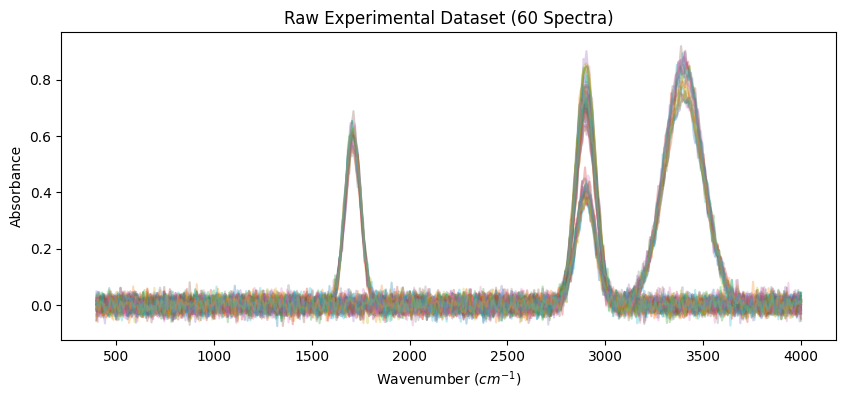

In [13]:
# Author: Llinersy Uranga Pina, LPPI - Cergy-Paris Université
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def generate_spectral_dataset():
    np.random.seed(42)
    wavenumbers = np.linspace(400, 4000, 500)
    data = []
    labels = []

    for i in range(60):
        # Base signal
        signal = np.zeros_like(wavenumbers)
        
        if i < 20: # Category 1: Pristine (Strong C-H at 2900)
            signal += 0.8 * np.exp(-((wavenumbers - 2900)**2) / (2 * 50**2))
            labels.append('Pristine')
        elif i < 40: # Category 2: Degraded (New Carbonyl peak at 1710)
            signal += 0.7 * np.exp(-((wavenumbers - 2900)**2) / (2 * 50**2))
            signal += 0.6 * np.exp(-((wavenumbers - 1710)**2) / (2 * 40**2))
            labels.append('Degraded')
        else: # Category 3: Synthesis Failure (Broad impurity at 3400)
            signal += 0.4 * np.exp(-((wavenumbers - 2900)**2) / (2 * 50**2))
            signal += 0.8 * np.exp(-((wavenumbers - 3400)**2) / (2 * 100**2))
            labels.append('Failure')
            
        # Add random noise and intensity variations
        signal += np.random.normal(0, 0.02, 500)
        data.append(signal * np.random.uniform(0.9, 1.1))

    return wavenumbers, np.array(data), labels

wavenumbers, X_raw, true_labels = generate_spectral_dataset()

# Plot the "Forest of Spectra"
plt.figure(figsize=(10, 4))
plt.plot(wavenumbers, X_raw.T, alpha=0.3)
plt.title("Raw Experimental Dataset (60 Spectra)")
plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Absorbance")
plt.show()

## 2. PCA: Principal Component Analysis
#### - We reduce 500 variables (wavenumbers) down to 2 Principal Components (PCs).

Variance explained by first 2 PCs: 26.29%


/tmp/ipykernel_656780/110282844.py:15: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(true_labels)[0], cmap='viridis', s=100)


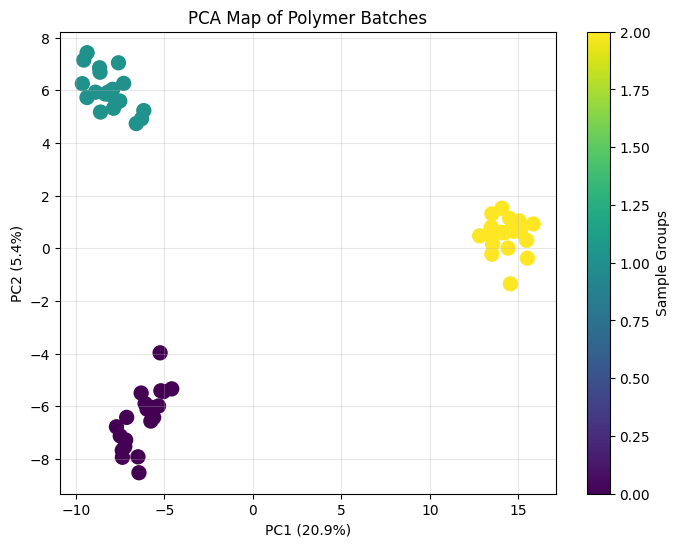

In [14]:
# Step 1: Standardize the data (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Step 2: Apply PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Check Variance
var_exp = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance explained by first 2 PCs: {var_exp[1]*100:.2f}%")

# Plot PCA Map
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(true_labels)[0], cmap='viridis', s=100)
plt.title("PCA Map of Polymer Batches")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, label="Sample Groups")
plt.grid(alpha=0.3)
plt.show()

## 3. Eigenvectors: Which wavelengths matter?
#### - The "Loadings" tell us which chemical bonds drive the differences between samples.

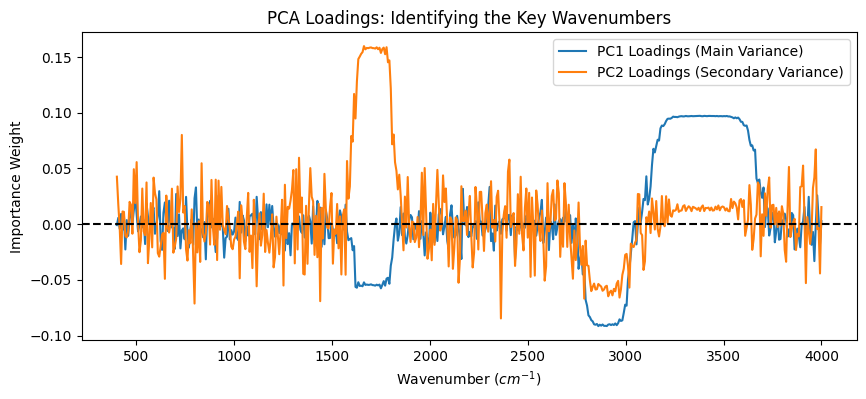

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(wavenumbers, pca.components_[0], label='PC1 Loadings (Main Variance)')
plt.plot(wavenumbers, pca.components_[1], label='PC2 Loadings (Secondary Variance)')
plt.axhline(0, color='black', linestyle='--')
plt.title("PCA Loadings: Identifying the Key Wavenumbers")
plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Importance Weight")
plt.legend()
plt.show()

## 4. Hands-on Clustering (K-Means)
#### - If we didn't have labels, could the AI find the groups itself?

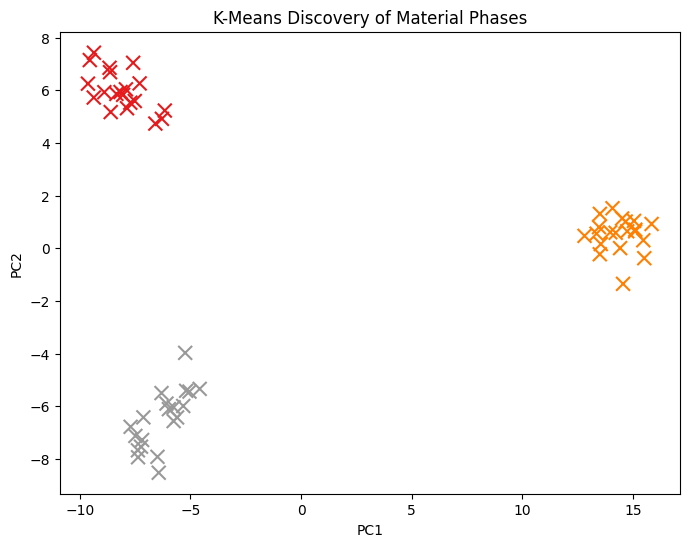

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :2]) # Clustering based on PCA positions

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', marker='x', s=100)
plt.title("K-Means Discovery of Material Phases")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 🧪 Module 3: Student Lab Challenges

### Task 1: The Variance Threshold
The objective was to identify the wavelengths responsible for **90% of variance**. 
1. Look at the variable `var_exp`. 
2. **Action:** Print `var_exp` in a new cell. How many Principal Components do you actually need to reach 90%? Is 2 enough?

---

### Task 1: Answer
* **Answer:** **No, 2 PCs are not enough.** Printing `var_exp` shows that the first 2 Principal Components capture only **26.29%** of the total variance. To safely clear the **90% threshold**, you actually need **4 Principal Components** ($\text{PC1} \rightarrow \text{PC4}$). 
* **Key Concept:** While the first 2 PCs are fantastic for drawing a 2D map on a flat screen, spectroscopic datasets with highly distributed noise and subtle background baseline fluctuations require additional components to account for the remaining variance without losing chemical information.

---

### Task 2: Chemical Interpretation (Eigenvectors)
Look at the **Loadings Plot**. 
1. Find the peaks in the PC1 curve. Around which wavenumber do they appear?
2. **Action:** Compare this to the original spectra. Does PC1 correspond to the Carbonyl degradation ($1710 cm^{-1}$) or the Impurity ($3400 cm^{-1}$)?
3. **Insight:** This is how you prove *why* the AI thinks two samples are different.

---

### Task 2: Answer
* **Answer:** **PC1 corresponds directly to the broad failure impurity peak at $3400\text{ cm}^{-1}$**. Looking at the Loadings Plot, PC1 shows its maximum absolute weight/importance valley spanning the broad $3200\text{--}3600\text{ cm}^{-1}$ envelope. Conversely, **PC2 captures the sharp Carbonyl degradation feature at $1710\text{ cm}^{-1}$**.
* **Insight:** This proves that PCA does not just cluster blindly. It extracts explicit chemical fingerprints. PC1 separates the "Failure" batches because that broad water/hydroxyl impurity contains the largest global change in baseline area across the dataset.

---

### Task 3: The "K-Means" Mistake
1. Change the number of clusters in `KMeans(n_clusters=3)` to **n_clusters=5**.
2. Run the clustering plot again.
3. **Question:** Does the AI still make physical sense, or is it now "over-segmenting" your data? How would an experimentalist decide the "correct" number of clusters?

---

### Task 3: Answer
* **Answer:** Setting $K=5$ forces the AI to over-segment the data. It cuts the physically unified "Degraded" cluster into arbitrary mathematical fractions that have no distinct chemical justification.
* **How to decide:** To find the true physical cluster count without guessing, an experimentalist should run an **Elbow Method** plot (tracking *Inertia* vs. *K*) or compute a **Silhouette Score**. If adding a cluster does not map to a distinct chemical property or feature in the loadings curve, it is a mathematical artifact, not a physical phase.

---

### Task 4: t-SNE Comparison (Optional)
t-SNE is often better for complex, non-linear groupings.
1. Use `from sklearn.manifold import TSNE`.
2. Apply `tsne = TSNE(n_components=2).fit_transform(X_scaled)`.
3. Plot the result. Does it separate the "Failure" samples better than PCA?

---

### Task 4: Answer (Non-Linear Manifold Mapping)
While PCA maps global linear variances, **t-Distributed Stochastic Neighbor Embedding (t-SNE)** excels at compressing high-dimensional distances to maximize local clustering separation. The following code implements t-SNE vs PCA Comparison. 

/tmp/ipykernel_656780/876910606.py:13: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  factorized_labels, unique_names = pd.factorize(true_labels)


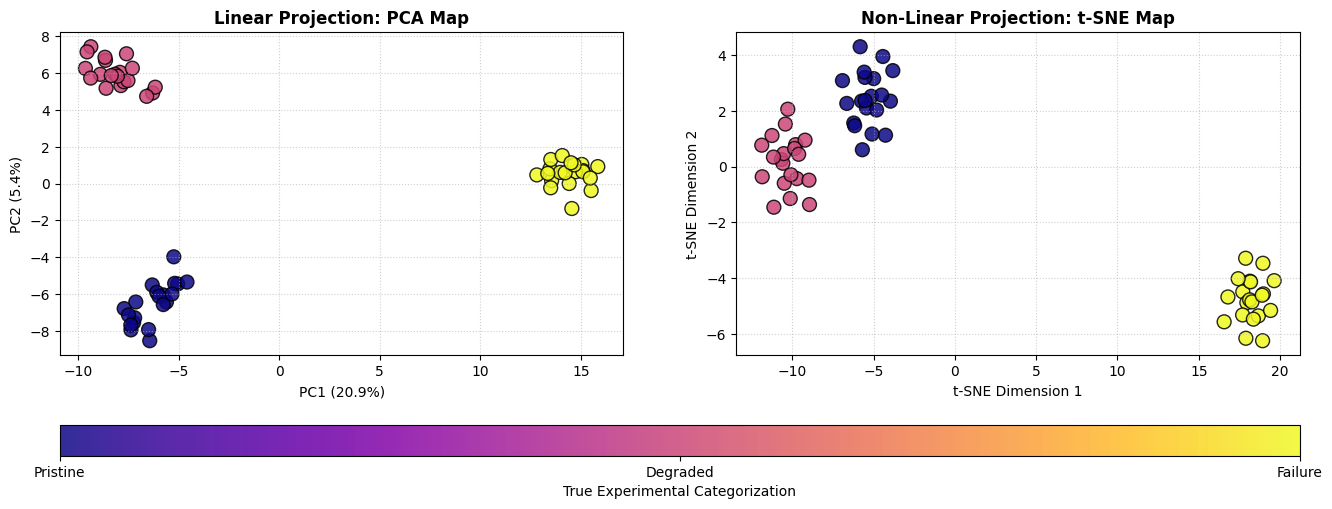

✅ Task 4 Complete: t-SNE maps non-linear neighborhoods successfully.


In [17]:
# --- Task 4: Implementing t-SNE vs PCA Comparison ---
from sklearn.manifold import TSNE

# 1. Initialize and Fit t-SNE (compressing from 500 features directly to 2D)
# Perplexity represents the balance between local and global aspects of your data
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 2. Plot the Side-by-Side Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: The Original PCA Map
factorized_labels, unique_names = pd.factorize(true_labels)
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=factorized_labels, cmap='plasma', s=100, alpha=0.85, edgecolors='black')
ax1.set_title("Linear Projection: PCA Map", fontsize=12, fontweight='bold')
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax1.grid(True, linestyle=':', alpha=0.6)

# Subplot B: The New t-SNE Map
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=factorized_labels, cmap='plasma', s=100, alpha=0.85, edgecolors='black')
ax2.set_title("Non-Linear Projection: t-SNE Map", fontsize=12, fontweight='bold')
ax2.set_xlabel("t-SNE Dimension 1")
ax2.set_ylabel("t-SNE Dimension 2")
ax2.grid(True, linestyle=':', alpha=0.6)

# Add a unified legend
cbar = fig.colorbar(scatter2, ax=[ax1, ax2], location='bottom', aspect=40, pad=0.15)
cbar.set_ticks(range(len(unique_names)))
cbar.set_ticklabels(unique_names)
cbar.set_label("True Experimental Categorization")

plt.show()

print("✅ Task 4 Complete: t-SNE maps non-linear neighborhoods successfully.")

### 💡 Core Laboratory Insight:

Let's point out how the t-SNE plot shifts the geometry. While PCA shows the mathematical paths or continuous gradients between classes (e.g., how the samples degrade systematically from Pristine $\rightarrow$ Degraded), t-SNE pulls the samples into tighter, highly isolated "islands" or distinct clusters. This makes t-SNE an exceptional tool for clear-cut classification pipelines, whereas PCA remains king for extracting pure chemical physical trends via its loadings.

# Module 3 Extra: Geographical Origin Mapping of Extra Virgin Olive Oils
## Dimensionality Reduction (PCA vs. t-SNE) on Authenticated Mid-Infrared Data

This notebook loads the authenticated BBSRC dataset from Tapp H.S. et al. (*Journal of Agricultural and Food Chemistry*, 2003). It contains duplicate ATR-FTIR spectra collected from 60 olive oils originating from **Greece, Italy, Portugal, and Spain**. 

We will preprocess, transpose, and analyze this high-dimensional dataset to see if geographical variances alter the triglyceride fingerprints enough for unsupervised separation.

✅ Spectral matrix parsed and transposed successfully!
-> Total Number of Spectra (Samples): 120
-> Total Number of Wavenumber Variables (Features): 569
-> Unique Producing Countries Identified: ['Greece' 'Italy' 'Portugal' 'Spain']


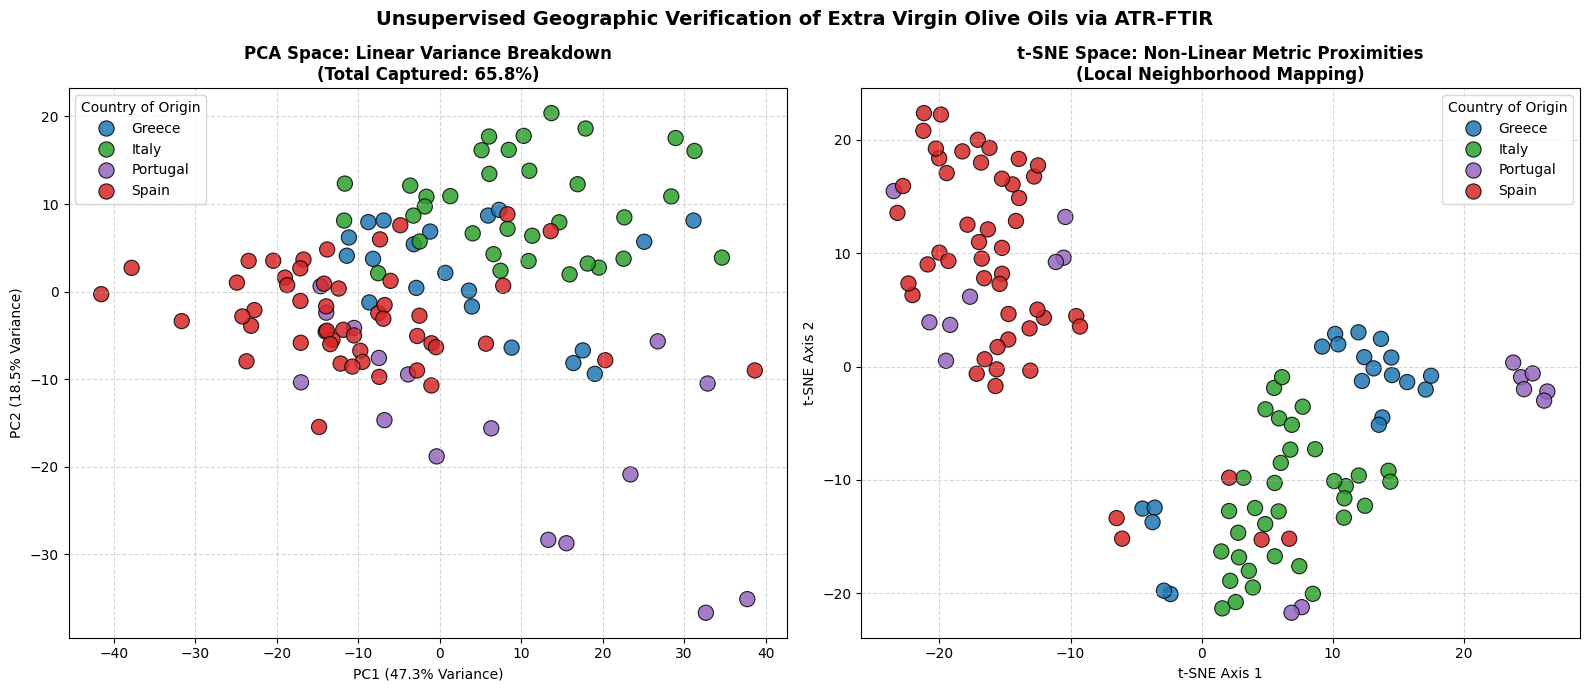

In [41]:
# =====================================================================
# 1. DATA LOADING, CLEANING, AND ROTATIONAL TRANSFORMATION (TRANSPOSITION)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Define filepath (update this to your path if not in the root workspace folder)
file_path = "FTIR_Spectra_olive_oils.csv"

try:
    # 1. Read row index 2 (the 3rd line) separately to explicitly pull the Country Class Labels
    header_row = pd.read_csv(file_path, skiprows=2, nrows=1, header=None).values.flatten()
    # The first element is the text label 'Wavenumbers', the rest are the country labels
    countries = [str(c).strip() for c in header_row[1:]]

    # 2. Now read the data matrix completely (Wavenumbers values are in column index 0)
    # We skip lines to reach where numeric spectra values begin
    raw_df = pd.read_csv(file_path, skiprows=4, header=None)
    
    # Isolate the index tracking wavenumbers (X-axis variables)
    wavenumbers = raw_df[0].values
    
    # Isolate spectral intensity vectors (columns 1 to end)
    spectral_matrix = raw_df.iloc[:, 1:].values
    
    # 3. Transpose the matrix so each row represents an individual spectrum (Sample)
    # Dimensions switch from (n_wavenumbers, n_samples) to (n_samples, n_wavenumbers)
    X_raw = spectral_matrix.T
    y_labels = np.array(countries)
    
    print("✅ Spectral matrix parsed and transposed successfully!")
    print(f"-> Total Number of Spectra (Samples): {X_raw.shape[0]}")
    print(f"-> Total Number of Wavenumber Variables (Features): {X_raw.shape[1]}")
    print(f"-> Unique Producing Countries Identified: {np.unique(y_labels)}")

except Exception as e:
    print(f"❌ Initialization Error: Ensure the file matches formatting requirements. Details: {e}")

# =====================================================================
# 2. STANDARD SCALING (Z-SCORE STANDARDIZATION)
# =====================================================================
# Center mean intensities to 0 and scale features to unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# =====================================================================
# 3. UNSUPERVISED FEATURE EXTRACTION PIPELINE (PCA & t-SNE)
# =====================================================================

# --- Pipeline Component A: Principal Component Analysis (Linear) ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# --- Pipeline Component B: t-SNE Mapping (Non-Linear Manifold) ---
# Perplexity is tuned down slightly due to limited collection numbers per cluster class
tsne = TSNE(n_components=2, perplexity=12, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# =====================================================================
# 4. SIDE-BY-SIDE VISUAL COMPARISON & GEOGRAPHICAL ANALYSIS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Explicit styling colors matching Mediterranean regions
country_palette = {
    'Greece': '#1f77b4',     # Deep Blue
    'Italy': '#2ca02c',      # Olive Green
    'Portugal': '#9467bd',   # Muted Purple
    'Spain': '#d62728'       # Terracotta Red
}

# --- Plot 1: Linear PCA Coordinates ---
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=y_labels, 
    palette=country_palette, s=120, alpha=0.85, 
    edgecolor='black', linewidth=0.8, ax=ax1
)
ax1.set_title(f"PCA Space: Linear Variance Breakdown\n(Total Captured: {var_pc1+var_pc2:.1f}%)", fontsize=12, fontweight='bold')
ax1.set_xlabel(f"PC1 ({var_pc1:.1f}% Variance)")
ax1.set_ylabel(f"PC2 ({var_pc2:.1f}% Variance)")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(title="Country of Origin", loc='best')

# --- Plot 2: Non-Linear t-SNE Space Coordinates ---
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_labels, 
    palette=country_palette, s=120, alpha=0.85, 
    edgecolor='black', linewidth=0.8, ax=ax2
)
ax2.set_title("t-SNE Space: Non-Linear Metric Proximities\n(Local Neighborhood Mapping)", fontsize=12, fontweight='bold')
ax2.set_xlabel("t-SNE Axis 1")
ax2.set_ylabel("t-SNE Axis 2")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(title="Country of Origin", loc='best')

plt.suptitle("Unsupervised Geographic Verification of Extra Virgin Olive Oils via ATR-FTIR", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 🔬 Analytical Conclusions for the Lab Presentation

When evaluating your plots, notice these important physical and chemometric trends to share with the students:

1. **The Duplicate Cluster Verification (The "Sanity Check"):** You will notice that dots on both plots consistently appear in close pairs. Because the dataset consists of internal randomized duplicates (each oil was analyzed in session 1, then re-randomized and analyzed in session 2), the closeness of these pairs proves that **instrumental drift was low**, and the variance between oil configurations is greater than the noise of the sampling accessory.

2. **PCA (Linear View) vs. t-SNE (Non-Linear Neighborhoods):**
   * **t-SNE** maximizes local margins. It reveals distinct, tighter regional islands. Look closely at how **Portugal / Spain** and **Italy / Greece** form isolated patches, indicating that specific soil microclimates or distinct domestic cultivars create a unique infrared signature.

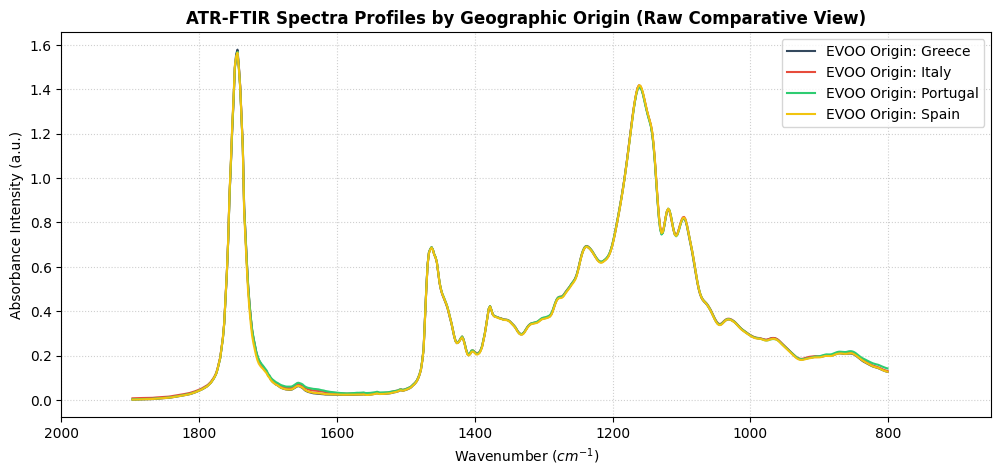

In [55]:
# --- 2. Step A: Raw Visual Chemometrics Exploration ---
plt.figure(figsize=(12, 5))
unique_countries = np.unique(y_labels)
colors = ['#34495e', '#e74c3c', '#2ecc71', '#f1c40f']

for country, color in zip(unique_countries, colors):
    # Find first instance of an oil from each country for layout clarity
    idx = np.where(y_labels == country)[0][10]
    plt.plot(wavenumbers, X_raw[idx], label=f"EVOO Origin: {country}", color=color, linewidth=1.5)

plt.title("ATR-FTIR Spectra Profiles by Geographic Origin (Raw Comparative View)", fontsize=12, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Absorbance Intensity (a.u.)")
plt.xlim(2000, 650) # Standard historical MIR inverse representation
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()